In [1]:
# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load dataset
df = pd.read_csv("/content/CAR DETAILS FROM CAR DEKHO.csv")

# Display first five rows
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
# Shape
print("Shape:", df.shape)

# Information
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

# Check duplicates
df.duplicated().sum()

Shape: (4340, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


np.int64(763)

In [6]:
df = df.drop_duplicates()

In [9]:
print(df['fuel'].unique())

print(df['seller_type'].unique())

print(df['transmission'].unique())

print(df['owner'].unique())

['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
['Individual' 'Dealer' 'Trustmark Dealer']
['Manual' 'Automatic']
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [10]:
cat_cols = ['fuel','seller_type','transmission','owner']

for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

In [12]:
current_year = 2025

df['car_age'] = current_year - df['year']

In [13]:
df['brand'] = df['name'].str.split().str[0]

In [30]:
df.drop(columns=['name', 'year'], inplace=True)

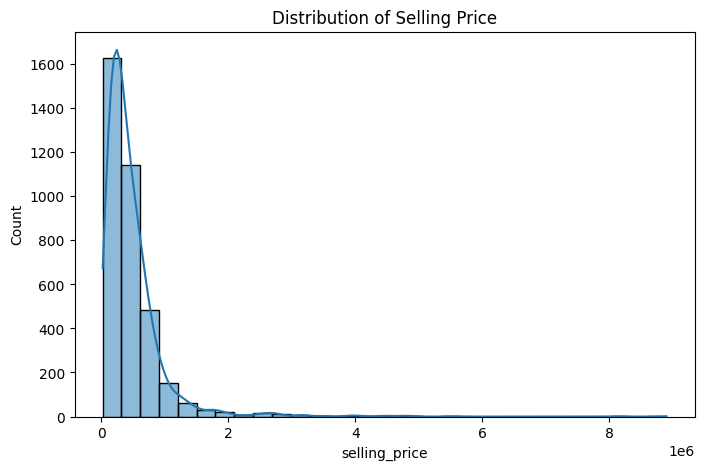

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df['selling_price'],
             bins=30,
             kde=True)

plt.title("Distribution of Selling Price")
plt.show()

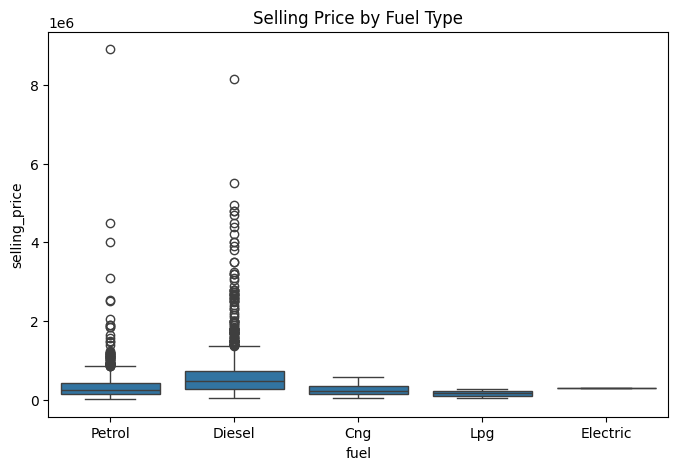

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='fuel',
            y='selling_price',
            data=df)

plt.title("Selling Price by Fuel Type")
plt.show()

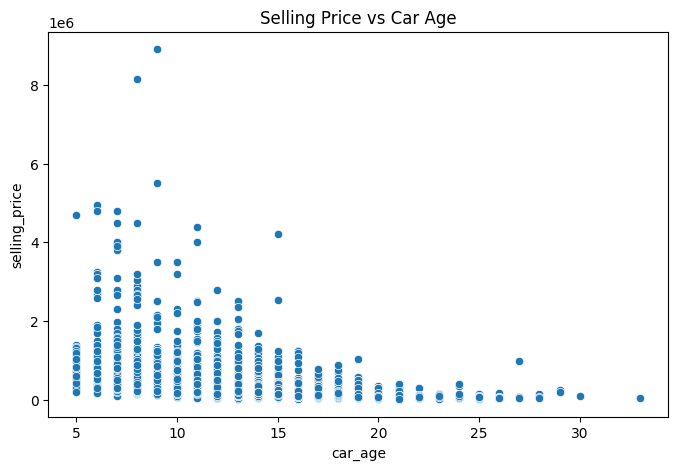

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='car_age',
                y='selling_price',
                data=df)

plt.title("Selling Price vs Car Age")
plt.show()

In [25]:
# Features
X = df.drop('selling_price', axis=1)

# Target
y = df['selling_price']

print(X.head())

                       name  year  km_driven    fuel seller_type transmission  \
0             Maruti 800 AC  2007      70000  Petrol  Individual       Manual   
1  Maruti Wagon R LXI Minor  2007      50000  Petrol  Individual       Manual   
2      Hyundai Verna 1.6 SX  2012     100000  Diesel  Individual       Manual   
3    Datsun RediGO T Option  2017      46000  Petrol  Individual       Manual   
4     Honda Amaze VX i-DTEC  2014     141000  Diesel  Individual       Manual   

          owner  car_age    brand  
0   First Owner       18   Maruti  
1   First Owner       18   Maruti  
2   First Owner       13  Hyundai  
3   First Owner        8   Datsun  
4  Second Owner       11    Honda  


In [24]:
# Categorical features
categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

# Numerical features
numeric_features = [
    'km_driven',
    'car_age'
]

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='passthrough'
)

In [32]:
print(df.columns)

Index(['selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission',
       'owner', 'car_age', 'brand'],
      dtype='object')


In [33]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [34]:
print(X.dtypes)

km_driven        int64
fuel            object
seller_type     object
transmission    object
owner           object
car_age          int64
brand           object
dtype: object


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    'fuel',
    'seller_type',
    'transmission',
    'owner',
    'brand'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2861, 7)
(716, 7)


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² :", lr_r2)

Linear Regression
MAE : 206780.770648276
RMSE: 426495.035883584
R² : 0.435333183933559


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [40]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² :", rf_r2)

Random Forest
MAE : 157680.8322111624
RMSE: 361616.6610699028
R² : 0.5940606344008761


In [41]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting")
print("MAE :", gb_mae)
print("RMSE:", gb_rmse)
print("R² :", gb_r2)

Gradient Boosting
MAE : 157977.33790614552
RMSE: 378101.1198160313
R² : 0.5562072203643689


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [42]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R² Score": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,206780.770648,426495.035884,0.435333
1,Random Forest,157680.832211,361616.661070,0.594061
2,Gradient Boosting,157977.337906,378101.119816,0.556207
